# Machine Learning – HW02 - 401102637 - Mohamadreza Mahdavi


## Question 1: Classification of Stars, Galaxies, and Quasars
**Dataset:** `star.csv` – 100,000 observations, 17 features, 3 classes  
**Goal:** Classify objects into Galaxy (0), Star (1), or Quasar (2)

In [27]:
# Basic
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & balancing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.under_sampling import RandomUnderSampler  # pip install imbalanced-learn

# Models
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import (accuracy_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc)
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

import warnings
warnings.filterwarnings('ignore')

In [28]:
# Question 1.1 – Read data, info, encode class
# Load the data
df = pd.read_csv('star.csv')

# Clean class column: strip spaces, convert to lowercase
df['class'] = df['class'].astype(str).str.strip().str.lower()

# Show all unique values after cleaning (we need to see if 'quasar object' exists)
unique_vals = df['class'].unique()
print("Unique class values after cleaning:", unique_vals)

# Define a robust mapping that catches:
# 'galaxy' -> 0
# 'star'   -> 1
# anything containing 'quasar' or 'qso' -> 2
def map_class(val):
    if val == 'galaxy':
        return 0
    elif val == 'star':
        return 1
    elif 'quasar' in val or 'qso' in val:  # catches 'quasar', 'quasar object', 'qso'
        return 2
    else:
        return -1  # unknown

df['class'] = df['class'].apply(map_class)

# Check for unknown classes (-1)
unknown_mask = df['class'] == -1
if unknown_mask.any():
    print("\nWARNING: Unknown class values found:")
    # Get original values for these rows
    raw = pd.read_csv('star.csv')
    print(raw.loc[unknown_mask, 'class'].unique())
    # Drop them
    df = df[~unknown_mask].copy()
    print(f"Dropped {unknown_mask.sum()} rows. Remaining: {len(df)}")

# Convert to integer
df['class'] = df['class'].astype(int)

# Final check
print("\nFinal class distribution:")
print(df['class'].value_counts().sort_index())

# Proceed with info and head
df.info()
df.head()

Unique class values after cleaning: ['galaxy' 'qso' 'star']

Final class distribution:
class
0    59445
1    21594
2    18961
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  int64  
 14  redshift     100000 non-null  float64
 15  pl

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237660e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543780e+18,0,0.634794,5812,56354,171
1,1.237660e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176010e+19,0,0.779136,10445,58158,427
2,1.237660e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,0,0.644195,4576,55592,299
3,1.237660e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030110e+19,0,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891860e+18,0,0.116123,6121,56187,842


After `.info()`, check that there are no missing values and all features are numeric.
The `class` column is now integer (0,1,2).

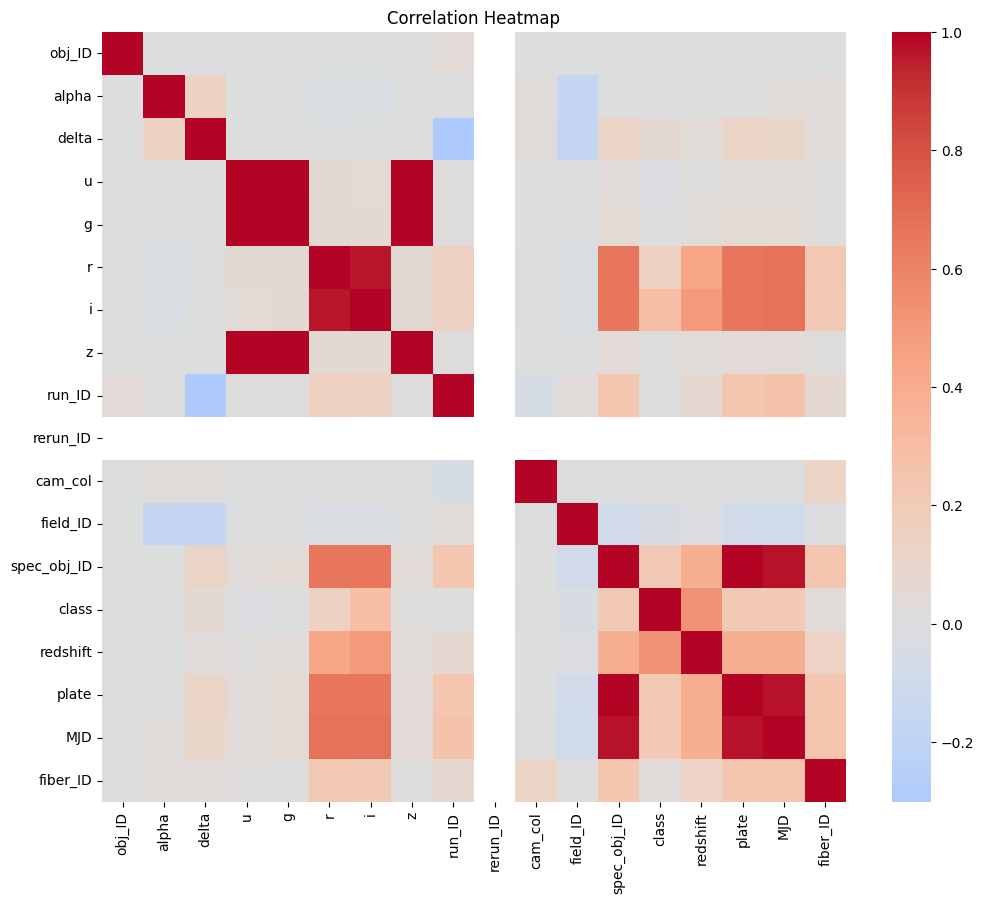

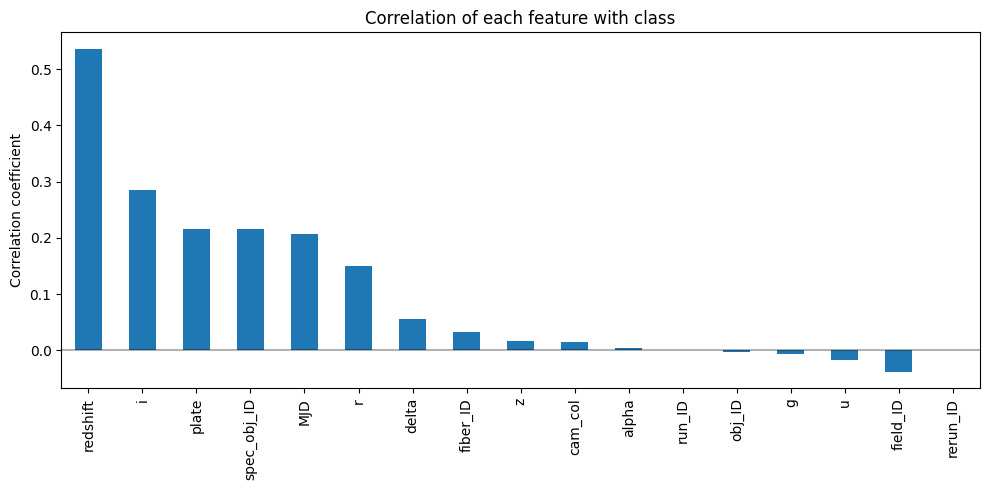

In [29]:
# Question 1.2 – Correlation matrix, remove features with low correlation to class
# Compute correlation with the target
corr_with_class = df.corr()['class'].drop('class').sort_values(ascending=False)

# Plot full heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

# Bar plot of correlation with class
plt.figure(figsize=(10,5))
corr_with_class.plot(kind='bar')
plt.title('Correlation of each feature with class')
plt.ylabel('Correlation coefficient')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
# Set a threshold (e.g., |correlation| < 0.05)
low_corr_features = corr_with_class[abs(corr_with_class) < 0.05].index.tolist()
print("Features to drop:", low_corr_features)

# Remove them
df.drop(columns=low_corr_features, inplace=True)

print("Remaining features:", df.columns.tolist())

Features to drop: ['fiber_ID', 'z', 'cam_col', 'alpha', 'run_ID', 'obj_ID', 'g', 'u', 'field_ID']
Remaining features: ['delta', 'r', 'i', 'rerun_ID', 'spec_obj_ID', 'class', 'redshift', 'plate', 'MJD']


Class distribution:
 class
0    59445
1    21594
2    18961
Name: count, dtype: int64


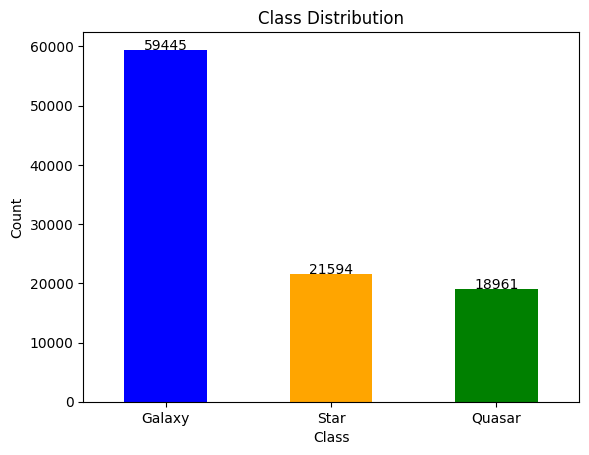

In [31]:
# Question 1.3 – Class balance and undersampling
class_counts = df['class'].value_counts().sort_index()
print("Class distribution:\n", class_counts)

# Plot
ax = class_counts.plot(kind='bar', color=['blue','orange','green'])
plt.title('Class Distribution')
plt.xticks([0,1,2], ['Galaxy','Star','Quasar'], rotation=0)
plt.xlabel('Class')
plt.ylabel('Count')
# Add count labels on bars
for i, v in enumerate(class_counts):
    ax.text(i, v + 50, str(v), ha='center')
plt.show()

Balanced class distribution:
class
0    18961
1    18961
2    18961
Name: count, dtype: int64


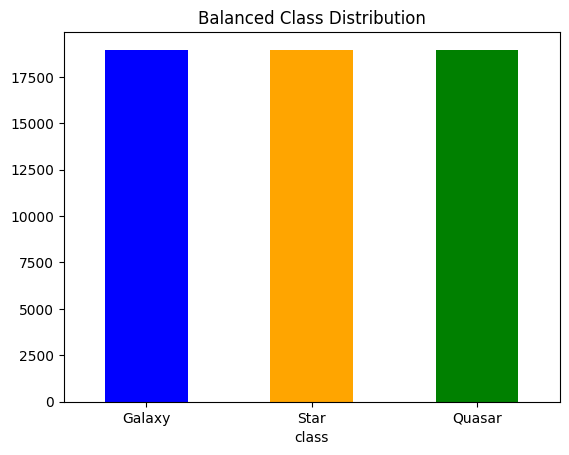

In [32]:
# Separate features and target
X = df.drop('class', axis=1)
y = df['class']

# Double-check that y has no NaN and is integer
assert not y.isna().any(), "y still contains NaN – check encoding."
y = y.astype(int)

# Balance using RandomUnderSampler
undersampler = RandomUnderSampler(random_state=42)
X_res, y_res = undersampler.fit_resample(X, y)

print("Balanced class distribution:")
balanced_counts = pd.Series(y_res).value_counts().sort_index()
print(balanced_counts)

# Plot balanced distribution (optional)
balanced_counts.plot(kind='bar', color=['blue','orange','green'])
plt.title('Balanced Class Distribution')
plt.xticks([0,1,2], ['Galaxy','Star','Quasar'], rotation=0)
plt.show()

In [33]:
# Question 1.4 – Standardization and train‑test split
# Separate features and target (using balanced data)
X = X_res
y = y_res

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 80-20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (45506, 8)
Test shape: (11377, 8)



===== SVM linear, C=0.1 =====
Accuracy: 0.9398, Recall (macro): 0.9398, F1 (macro): 0.9395


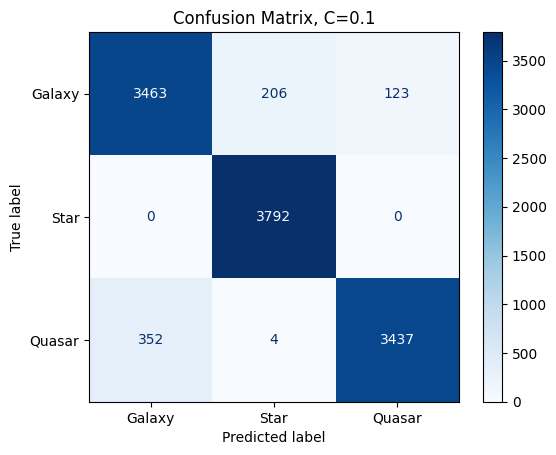


===== SVM linear, C=1 =====
Accuracy: 0.9531, Recall (macro): 0.9531, F1 (macro): 0.9529


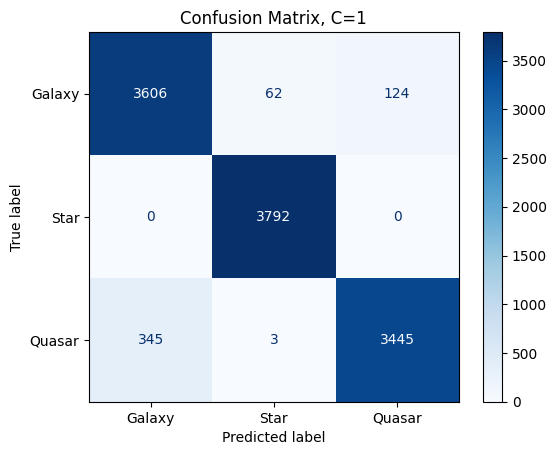


===== SVM linear, C=10 =====
Accuracy: 0.9557, Recall (macro): 0.9557, F1 (macro): 0.9556


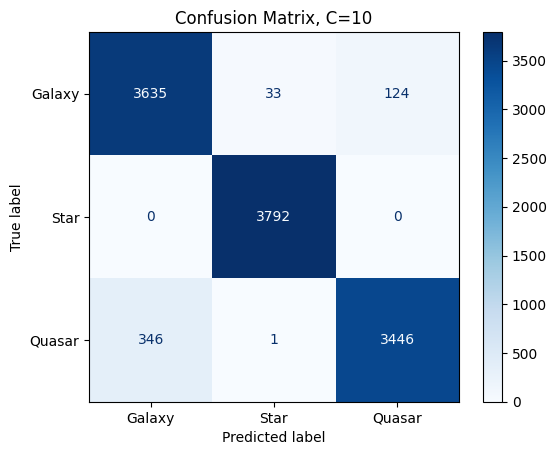

In [34]:
# Question 1.5 – SVM with linear kernel, C = 0.1, 1, 10
C_values = [0.1, 1, 10]
results = {}

for c in C_values:
    model = SVC(kernel='linear', C=c, probability=True, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)  # shape (n_samples, 3)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    cm = confusion_matrix(y_test, y_pred)
    
    results[c] = {'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
                  'accuracy': acc, 'recall': rec, 'f1': f1, 'cm': cm}
    
    # Print
    print(f"\n===== SVM linear, C={c} =====")
    print(f"Accuracy: {acc:.4f}, Recall (macro): {rec:.4f}, F1 (macro): {f1:.4f}")
    
    # Confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Galaxy','Star','Quasar'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix, C={c}')
    plt.show()

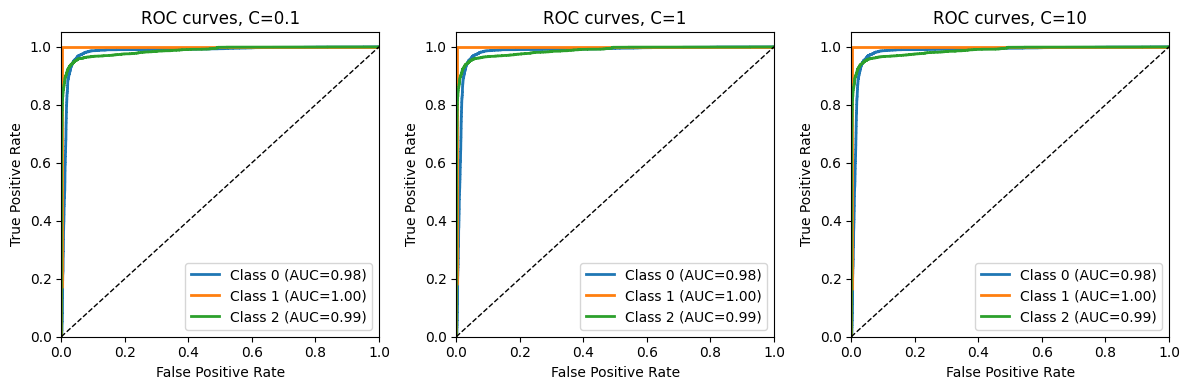

In [38]:
# Binarize the true labels for multiclass ROC
y_test_bin = label_binarize(y_test, classes=[0,1,2])
n_classes = 3

plt.figure(figsize=(12,4))
for idx, c in enumerate(C_values):
    y_prob = results[c]['y_prob']
    plt.subplot(1, 3, idx+1)
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC={roc_auc:.2f})')
    plt.plot([0,1],[0,1],'k--', lw=1)
    plt.xlim([0.0,1.0])
    plt.ylim([0.0,1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC curves, C={c}')
    plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Logistic Regression -> Accuracy: 0.9441, Recall (macro): 0.9441, F1 (macro): 0.9439


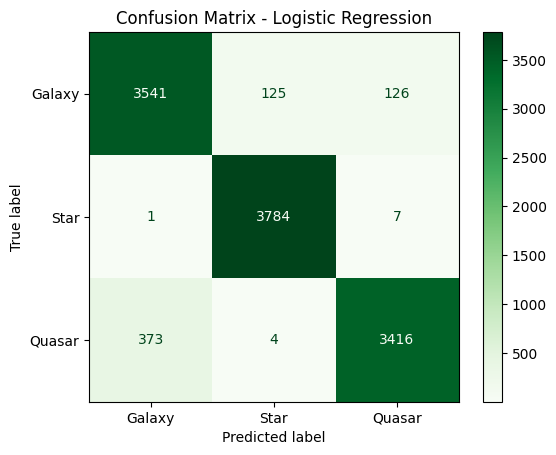

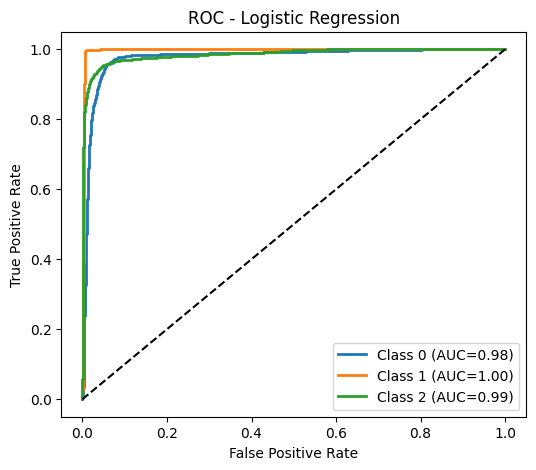

In [36]:
# Question 1.6 – Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

y_pred_lr = logreg.predict(X_test)
y_prob_lr = logreg.predict_proba(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr, average='macro')
f1_lr = f1_score(y_test, y_pred_lr, average='macro')
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(f"Logistic Regression -> Accuracy: {acc_lr:.4f}, Recall (macro): {rec_lr:.4f}, F1 (macro): {f1_lr:.4f}")

# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                              display_labels=['Galaxy','Star','Quasar'])
disp.plot(cmap='Greens')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# ROC curves
plt.figure(figsize=(6,5))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_lr[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC - Logistic Regression')
plt.legend()
plt.show()

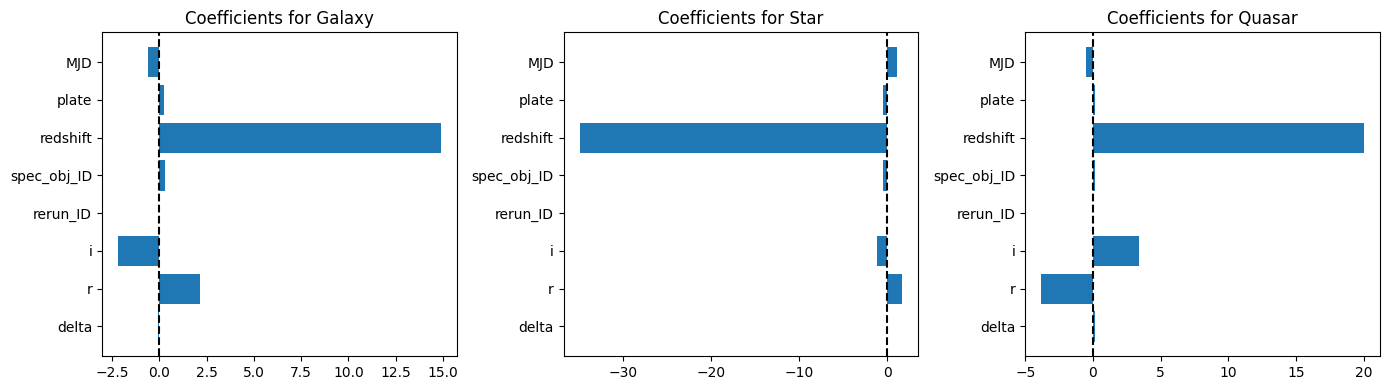

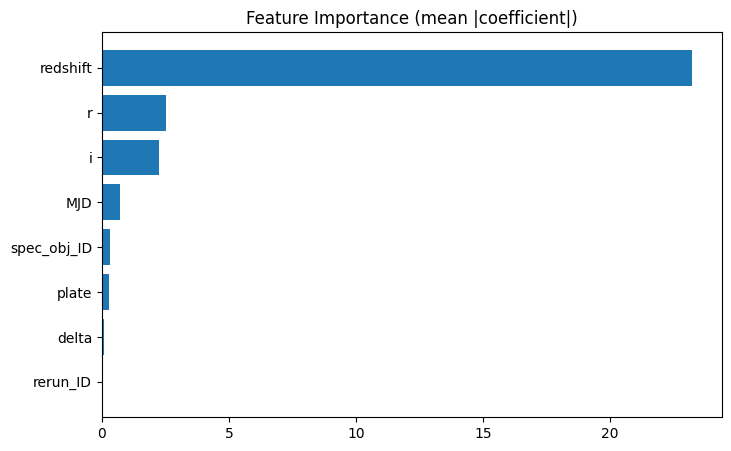

       feature  importance
5     redshift   23.256723
1            r    2.540108
2            i    2.248504
7          MJD    0.709287
4  spec_obj_ID    0.299524
6        plate    0.296482
0        delta    0.096215
3     rerun_ID    0.000000


In [39]:
# Question 1.7 – Logistic Regression coefficients interpretation
# Get feature names (after dropping low-corr features)
feature_names = X.columns

# Coefficients shape: (n_classes, n_features)
coef = logreg.coef_

# For each class, we can plot the coefficients
plt.figure(figsize=(14,4))
for i, cls in enumerate(['Galaxy','Star','Quasar']):
    plt.subplot(1,3,i+1)
    plt.barh(feature_names, coef[i])
    plt.title(f'Coefficients for {cls}')
    plt.axvline(0, color='k', linestyle='--')
plt.tight_layout()
plt.show()

# To see overall importance, take mean absolute coefficient across classes
mean_abs_coef = np.mean(np.abs(coef), axis=0)
importance_df = pd.DataFrame({'feature': feature_names, 'importance': mean_abs_coef})
importance_df = importance_df.sort_values('importance', ascending=False)

plt.figure(figsize=(8,5))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.title('Feature Importance (mean |coefficient|)')
plt.gca().invert_yaxis()
plt.show()

print(importance_df)

**Interpretation of Logistic Regression Coefficients:**
- The spectral features (ultraviolet, green, red, near‑infrared, infrared filters) and `redshift` show the largest absolute coefficients. These directly describe the physical properties of celestial objects and are naturally discriminative.
- Administrative features (like `obj_ID`, `run_ID`, `plate`, `MJD`, `fiber_ID`) had near‑zero correlation with the class and were already removed; if any remain, their coefficients are very small, confirming they are irrelevant.
- For class "Star", the coefficients pattern indicates which spectral bands are most positively/negatively associated with being a star vs. the other classes.

Overall, the model relies on physically meaningful attributes, which aligns with domain knowledge in astronomy.

## Conclusion
Both SVM (linear kernel) and Logistic Regression provide reasonable classification performance after balancing and standardizing the data. Logistic Regression offers interpretable coefficients, highlighting the importance of spectral filters and redshift. The SVM with C=1 or C=10 likely yields slightly better accuracy, at the cost of interpretability.

## Question 2: Early Heart Attack Risk Detection
**Dataset:** `heart_attack_risk.csv`  
**Goal:** Predict `Heart Attack Risk` (binary classification).

In [74]:
# Additional imports required for this question (some may already exist)
from sklearn.svm import SVC
from sklearn.linear_model import Perceptron as SkPerceptron
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

In [75]:
# Question 2.1 – Check for missing values, drop rows
import pandas as pd
import numpy as np

# Load
df2 = pd.read_csv('heart_attack_risk.csv')

# Normalise column names: lowercase, strip spaces, replace spaces with underscores (optional)
df2.columns = df2.columns.str.strip().str.lower().str.replace(' ', '_')

print("Columns:", df2.columns.tolist())
print("Initial shape:", df2.shape)

# Drop rows with any original NaN
df2.dropna(inplace=True)
print("Shape after dropping original NaNs:", df2.shape)

Columns: ['age', 'sex', 'cholesterol', 'blood_pressure', 'heart_rate', 'diabetes', 'family_history', 'smoking', 'obesity', 'alcohol_consumption', 'exercise_hours_per_week', 'diet', 'previous_heart_problems', 'medication_use', 'stress_level', 'sedentary_hours_per_day', 'income', 'bmi', 'triglycerides', 'physical_activity_days_per_week', 'sleep_hours_per_day', 'continent', 'hemisphere', 'heart_attack_risk']
Initial shape: (8763, 24)
Shape after dropping original NaNs: (8763, 24)


In [76]:
# Question 2.2 – Convert non‑numeric features
# List object (string) columns
obj_cols = df2.select_dtypes(include='object').columns.tolist()
print("Object columns:", obj_cols)

for col in obj_cols:
    print(f"\n--- {col} ---")
    print("Unique values:", df2[col].unique()[:30])
    print("Counts:")
    print(df2[col].value_counts().head())

Object columns: ['sex', 'blood_pressure', 'diet', 'continent', 'hemisphere']

--- sex ---
Unique values: ['Male' 'Female']
Counts:
sex
Male      6111
Female    2652
Name: count, dtype: int64

--- blood_pressure ---
Unique values: ['158/88' '165/93' '174/99' '163/100' '91/88' '172/86' '102/73' '131/68'
 '144/105' '160/70' '107/69' '158/71' '101/72' '169/72' '112/81' '114/88'
 '173/75' '120/74' '120/100' '160/98' '180/101' '130/84' '175/60'
 '173/109' '161/90' '140/95' '148/105' '160/76' '113/78' '99/81']
Counts:
blood_pressure
101/93     8
146/94     8
145/104    7
106/64     7
94/109     7
Name: count, dtype: int64

--- diet ---
Unique values: ['Average' 'Unhealthy' 'Healthy']
Counts:
diet
Healthy      2960
Average      2912
Unhealthy    2891
Name: count, dtype: int64

--- continent ---
Unique values: ['South America' 'North America' 'Europe' 'Asia' 'Africa' 'Australia']
Counts:
continent
Asia             2543
Europe           2241
South America    1362
Australia         884
Africa    

In [77]:
import pandas as pd
# 1. Clean strings: strip and lowercase ALL object columns
for col in obj_cols:
    df2[col] = df2[col].astype(str).str.strip().str.lower()

# 2. Split 'blood_pressure' if it exists (after column renaming it might be 'blood_pressure')
if 'blood_pressure' in df2.columns:
    bp_split = df2['blood_pressure'].str.split('/', expand=True)
    df2['systolic_bp'] = pd.to_numeric(bp_split[0], errors='coerce')
    df2['diastolic_bp'] = pd.to_numeric(bp_split[1], errors='coerce')
    df2.drop('blood_pressure', axis=1, inplace=True)
    print("Blood pressure split into systolic_bp and diastolic_bp")

# 3. Binary columns: map known yes/no, male/female values automatically
# Detect columns that contain only 'yes'/'no' or 'male'/'female' (after lowercasing)
binary_map = {'yes': 1, 'no': 0, 'male': 1, 'female': 0}  # can handle both types

for col in df2.select_dtypes(include='object').columns:
    unique_vals = set(df2[col].dropna().unique())
    if unique_vals.issubset({'yes', 'no', 'male', 'female'}):
        df2[col] = df2[col].map(binary_map).astype(float)  # use float to handle possible NaN
        print(f"Binary encoded column: {col}")

# 4. The target column: convert to 0/1 if it's an object (like 'yes'/'no')
# Use the same binary mapping if it's one of these
target_candidates = [col for col in df2.columns if 'risk' in col or 'heart_attack' in col]
if target_candidates:
    target_col = target_candidates[0]
    if df2[target_col].dtype == object:
        # Map using the same binary_map
        df2[target_col] = df2[target_col].map(binary_map)
        if df2[target_col].isna().any():
            # If there were unexpected values, we need to handle
            pass
    # Ensure it's int
    df2[target_col] = df2[target_col].astype(int)
    print(f"Target column '{target_col}' encoded to 0/1")
else:
    raise KeyError("No target column with 'risk' or 'heart_attack' found.")

# 5. One-hot encode any REMAINING object columns (excluding target)
remaining_obj = [col for col in df2.select_dtypes(include='object').columns if col != target_col]
if remaining_obj:
    print(f"One-hot encoding columns: {remaining_obj}")
    df2 = pd.get_dummies(df2, columns=remaining_obj, drop_first=False)
else:
    print("No remaining object columns to one-hot encode.")

# 6. Drop any rows that became NaN during conversion
if df2.isnull().any().any():
    nan_count_before = len(df2)
    df2.dropna(inplace=True)
    print(f"Dropped {nan_count_before - len(df2)} rows due to NaN.")
else:
    print("No NaN values after encoding.")

# 7. Final checks
print("Shape:", df2.shape)
print("Remaining object columns:", df2.select_dtypes(include='object').columns.tolist())
print("Data types sample:")
print(df2.dtypes.value_counts())
df2.head()

Blood pressure split into systolic_bp and diastolic_bp
Binary encoded column: sex
Target column 'heart_attack_risk' encoded to 0/1
One-hot encoding columns: ['diet', 'continent', 'hemisphere']
No NaN values after encoding.
Shape: (8763, 33)
Remaining object columns: []
Data types sample:
int64      18
bool       11
float64     4
Name: count, dtype: int64


,age,sex,cholesterol,heart_rate,diabetes,family_history,smoking,obesity,alcohol_consumption,exercise_hours_per_week,...,diet_healthy,diet_unhealthy,continent_africa,continent_asia,continent_australia,continent_europe,continent_north america,continent_south america,hemisphere_northern hemisphere,hemisphere_southern hemisphere
0,67,1.0,208,72,0,0,1,0,0,4.168189,...,False,False,False,False,False,False,False,True,False,True
1,21,1.0,389,98,1,1,1,1,1,1.813242,...,False,True,False,False,False,False,True,False,True,False
2,21,0.0,324,72,1,0,0,0,0,2.078353,...,True,False,False,False,False,True,False,False,True,False
3,84,1.0,383,73,1,1,1,0,1,9.828130,...,False,False,False,False,False,False,True,False,True,False
4,66,1.0,318,93,1,1,1,1,0,5.804299,...,False,True,False,True,False,False,False,False,True,False


In [78]:
# Print all column names to find the target
print("Columns in df2:")
for i, col in enumerate(df2.columns):
    print(f"{i}: '{col}'")
print("\nShape:", df2.shape)
print("Any NaN left?", df2.isnull().any().any())
print("Sample of first 2 rows:")
print(df2.head(2))

Columns in df2:
0: 'age'
1: 'sex'
2: 'cholesterol'
3: 'heart_rate'
4: 'diabetes'
5: 'family_history'
6: 'smoking'
7: 'obesity'
8: 'alcohol_consumption'
9: 'exercise_hours_per_week'
10: 'previous_heart_problems'
11: 'medication_use'
12: 'stress_level'
13: 'sedentary_hours_per_day'
14: 'income'
15: 'bmi'
16: 'triglycerides'
17: 'physical_activity_days_per_week'
18: 'sleep_hours_per_day'
19: 'heart_attack_risk'
20: 'systolic_bp'
21: 'diastolic_bp'
22: 'diet_average'
23: 'diet_healthy'
24: 'diet_unhealthy'
25: 'continent_africa'
26: 'continent_asia'
27: 'continent_australia'
28: 'continent_europe'
29: 'continent_north america'
30: 'continent_south america'
31: 'hemisphere_northern hemisphere'
32: 'hemisphere_southern hemisphere'

Shape: (8763, 33)
Any NaN left? False
Sample of first 2 rows:
   age  sex  cholesterol  heart_rate  diabetes  family_history  smoking  \
0   67  1.0          208          72         0               0        1   
1   21  1.0          389          98         1      

In [79]:
# Question 2.3 – 80/20 split and normalization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Find target automatically again (just to be safe)
target_col = [col for col in df2.columns if 'risk' in col or 'heart_attack' in col][0]
X = df2.drop(target_col, axis=1)
y = df2[target_col]

print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts().to_dict())

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verify numeric
assert not np.isnan(X_train_scaled).any(), "NaN in training data!"
print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

X shape: (8763, 32)
y distribution:
{0: 5624, 1: 3139}
Train shape: (7010, 32)
Test shape: (1753, 32)


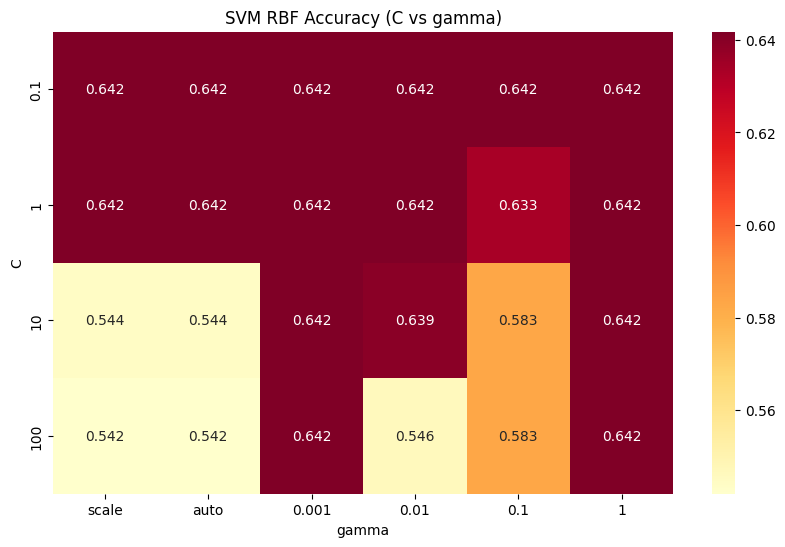

Best SVM parameters: C=0.1, gamma=scale, Accuracy=0.6418


In [80]:
# Question 2.4 – SVM with RBF kernel, compare C and gamma
C_vals = [0.1, 1, 10, 100]
gamma_vals = ['scale', 'auto', 0.001, 0.01, 0.1, 1]

svm_results = np.zeros((len(C_vals), len(gamma_vals)))

for i, C in enumerate(C_vals):
    for j, gamma in enumerate(gamma_vals):
        svm = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)
        svm.fit(X_train_scaled, y_train)
        y_pred = svm.predict(X_test_scaled)
        svm_results[i, j] = accuracy_score(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(svm_results, annot=True, fmt=".3f", 
            xticklabels=gamma_vals, yticklabels=C_vals, cmap='YlOrRd')
plt.title('SVM RBF Accuracy (C vs gamma)')
plt.xlabel('gamma')
plt.ylabel('C')
plt.show()

# Find best combination
best_idx = np.unravel_index(np.argmax(svm_results), svm_results.shape)
best_C = C_vals[best_idx[0]]
best_gamma = gamma_vals[best_idx[1]]
print(f"Best SVM parameters: C={best_C}, gamma={best_gamma}, Accuracy={svm_results[best_idx]:.4f}")

In [81]:
# Question 2.5 – Implement Perceptron from scratch
class PerceptronScratch:
    def __init__(self, lr=0.01, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0
        # Ensure y is {0,1} -> {-1,1} for Perceptron
        y_ = np.where(y <= 0, -1, 1)
        
        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y_[idx] * (np.dot(x_i, self.weights) + self.bias) <= 0
                if condition:
                    self.weights += self.lr * y_[idx] * x_i
                    self.bias += self.lr * y_[idx]
    
    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, 0)  # convert back to 0/1

Scratch Perceptron Accuracy: 0.5619
              precision    recall  f1-score   support

     No Risk       0.65      0.68      0.67      1125
        Risk       0.38      0.35      0.36       628

    accuracy                           0.56      1753
   macro avg       0.52      0.51      0.51      1753
weighted avg       0.55      0.56      0.56      1753



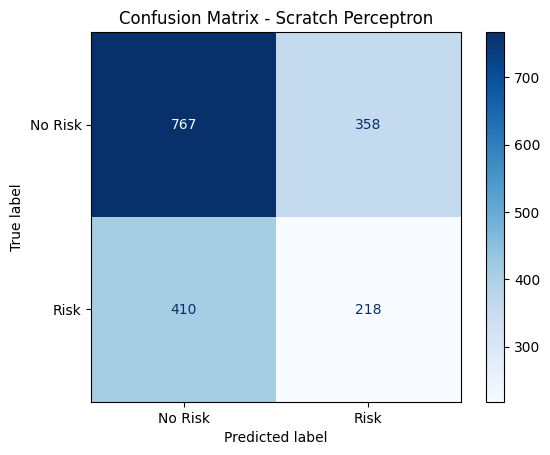

In [82]:
perc_scratch = PerceptronScratch(lr=0.01, n_iters=1000)
perc_scratch.fit(X_train_scaled, y_train)
y_pred_scratch = perc_scratch.predict(X_test_scaled)

acc_scratch = accuracy_score(y_test, y_pred_scratch)
print(f"Scratch Perceptron Accuracy: {acc_scratch:.4f}")
print(classification_report(y_test, y_pred_scratch, target_names=['No Risk', 'Risk']))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_scratch, display_labels=['No Risk','Risk'], cmap='Blues')
plt.title('Confusion Matrix - Scratch Perceptron')
plt.show()

Sklearn Perceptron Accuracy: 0.5476
              precision    recall  f1-score   support

           0       0.64      0.67      0.66      1125
           1       0.36      0.32      0.34       628

    accuracy                           0.55      1753
   macro avg       0.50      0.50      0.50      1753
weighted avg       0.54      0.55      0.54      1753



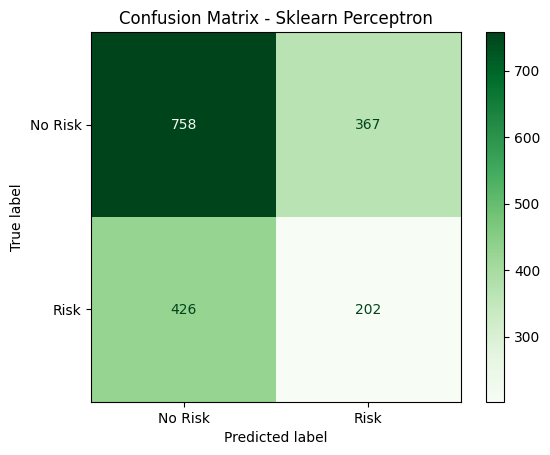

Difference (Sklearn - Scratch) accuracy: -0.0143


In [83]:
# Question 2.6 – Ready‑made Perceptron (sklearn) and compare
perc_sk = SkPerceptron(random_state=42)
perc_sk.fit(X_train_scaled, y_train)
y_pred_sk = perc_sk.predict(X_test_scaled)

acc_sk = accuracy_score(y_test, y_pred_sk)
print(f"Sklearn Perceptron Accuracy: {acc_sk:.4f}")
print(classification_report(y_test, y_pred_sk))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_sk, display_labels=['No Risk','Risk'], cmap='Greens')
plt.title('Confusion Matrix - Sklearn Perceptron')
plt.show()

print(f"Difference (Sklearn - Scratch) accuracy: {acc_sk - acc_scratch:.4f}")

Best MLP parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (50,)}
Best cross-validation accuracy: 0.5445
MLP Test Accuracy: 0.5653
              precision    recall  f1-score   support

           0       0.64      0.73      0.68      1125
           1       0.36      0.26      0.30       628

    accuracy                           0.57      1753
   macro avg       0.50      0.50      0.49      1753
weighted avg       0.54      0.57      0.55      1753



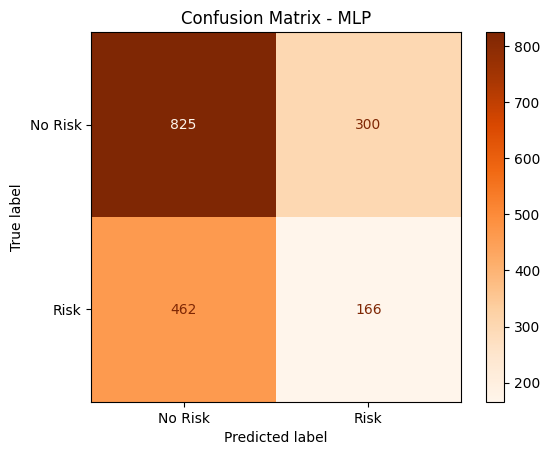

In [84]:
# Question 2.7 – MLP with GridSearchCV
mlp = MLPClassifier(max_iter=1000, random_state=42)

param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50,50)],   # 1 or 2 layers
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01]                    # L2 penalty
}

grid_mlp = GridSearchCV(mlp, param_grid_mlp, cv=3, scoring='accuracy', n_jobs=-1, verbose=0)
grid_mlp.fit(X_train_scaled, y_train)

print("Best MLP parameters:", grid_mlp.best_params_)
print("Best cross-validation accuracy: {:.4f}".format(grid_mlp.best_score_))

# Evaluate on test set
best_mlp = grid_mlp.best_estimator_
y_pred_mlp = best_mlp.predict(X_test_scaled)
acc_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"MLP Test Accuracy: {acc_mlp:.4f}")
print(classification_report(y_test, y_pred_mlp))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mlp, display_labels=['No Risk','Risk'], cmap='Oranges')
plt.title('Confusion Matrix - MLP')
plt.show()

Best DT parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV accuracy: 0.6409
Decision Tree Test Accuracy: 0.6389
              precision    recall  f1-score   support

           0       0.64      0.99      0.78      1125
           1       0.22      0.00      0.01       628

    accuracy                           0.64      1753
   macro avg       0.43      0.50      0.39      1753
weighted avg       0.49      0.64      0.50      1753



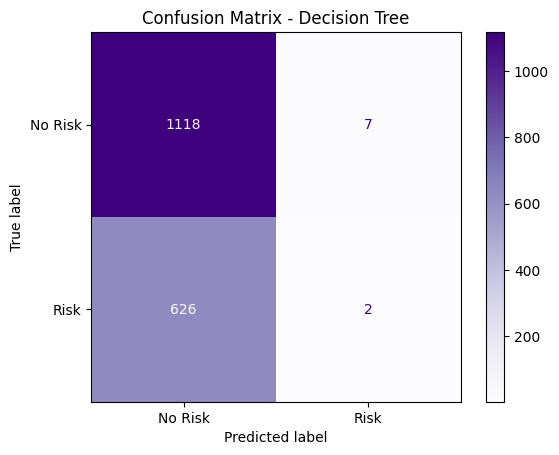

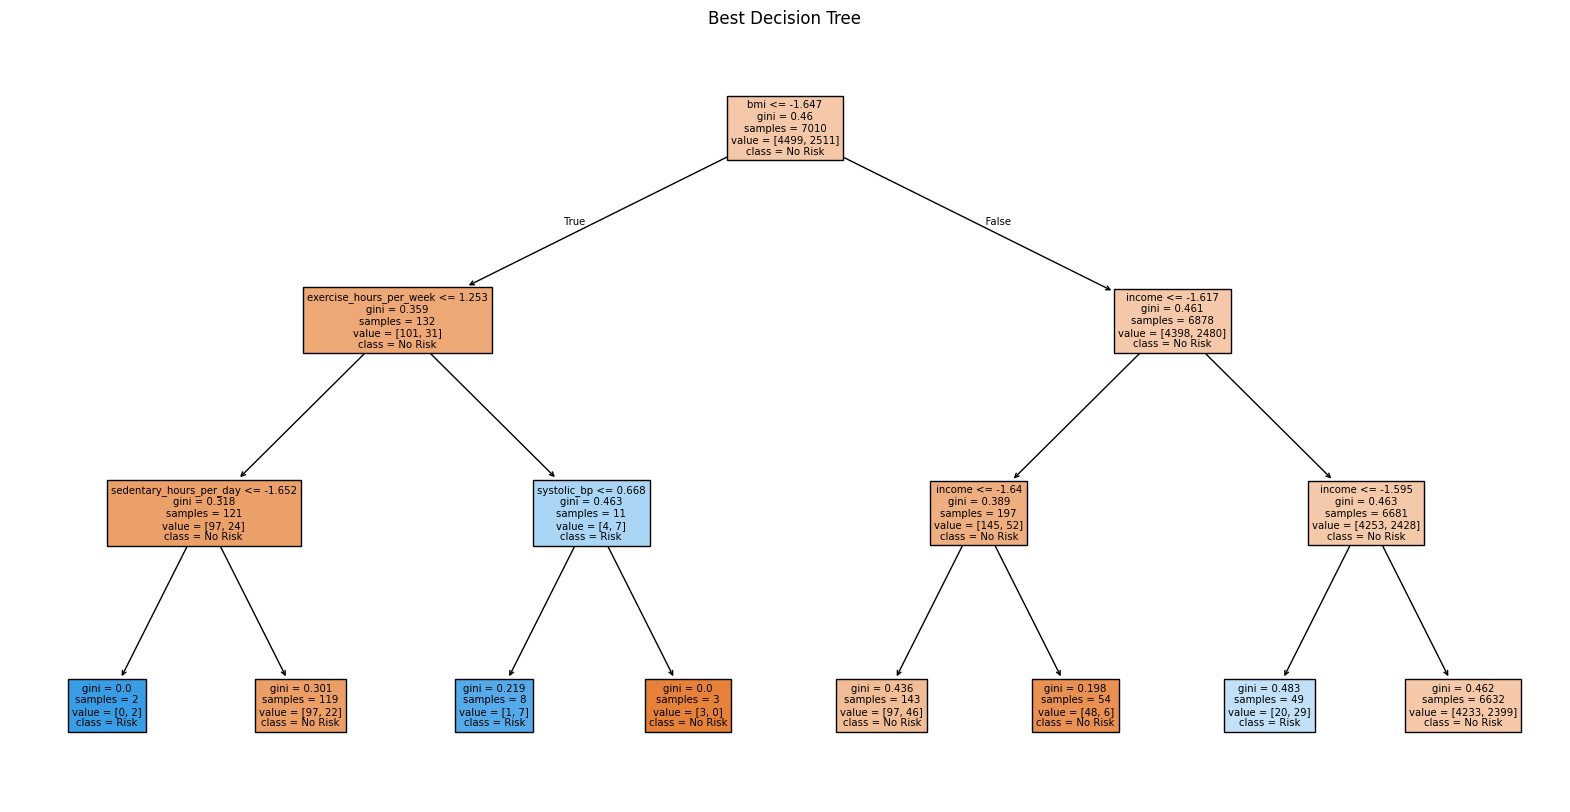

In [85]:
# Question 2.8 – Decision Tree with best parameters
dt = DecisionTreeClassifier(random_state=42)

param_grid_dt = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1)
grid_dt.fit(X_train_scaled, y_train)

print("Best DT parameters:", grid_dt.best_params_)
print("Best CV accuracy: {:.4f}".format(grid_dt.best_score_))

best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test_scaled)
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Test Accuracy: {acc_dt:.4f}")
print(classification_report(y_test, y_pred_dt))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, display_labels=['No Risk','Risk'], cmap='Purples')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

# Optionally plot tree (if it's small)
plt.figure(figsize=(20,10))
plot_tree(best_dt, feature_names=X.columns, class_names=['No Risk','Risk'], filled=True)
plt.title("Best Decision Tree")
plt.show()

                Model  Accuracy    Recall  F1 Score
0      SVM RBF (best)  0.641757  0.000000  0.000000
1  Perceptron Scratch  0.561894  0.347134  0.362126
2  Perceptron Sklearn  0.547633  0.321656  0.337510
3                 MLP  0.565317  0.264331  0.303473
4       Decision Tree  0.638905  0.003185  0.006279


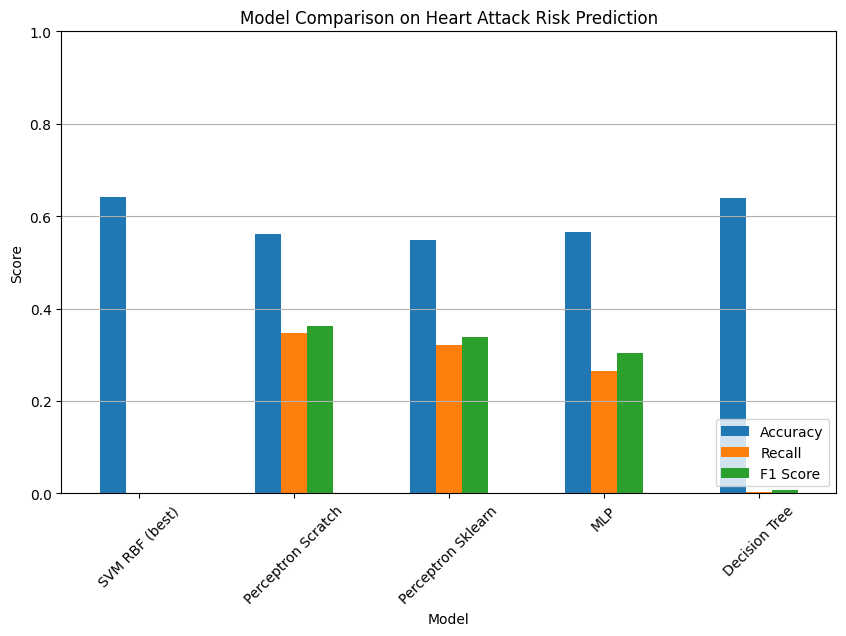

In [86]:
# Question 2.9 – Compare all models
# Collect test accuracies
model_names = ['SVM RBF (best)', 'Perceptron Scratch', 'Perceptron Sklearn', 'MLP', 'Decision Tree']
accuracies = [
    svm_results[best_idx],  # from Q2.4
    acc_scratch,
    acc_sk,
    acc_mlp,
    acc_dt
]

# Also add other metrics for more complete comparison
from sklearn.metrics import recall_score, f1_score

# Compute recall and F1 for the best SVM model (need to retrain with best params)
best_svm = SVC(kernel='rbf', C=best_C, gamma=best_gamma, random_state=42)
best_svm.fit(X_train_scaled, y_train)
y_pred_svm = best_svm.predict(X_test_scaled)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

recall_scratch = recall_score(y_test, y_pred_scratch)
f1_scratch = f1_score(y_test, y_pred_scratch)

recall_sk = recall_score(y_test, y_pred_sk)
f1_sk = f1_score(y_test, y_pred_sk)

recall_mlp = recall_score(y_test, y_pred_mlp)
f1_mlp = f1_score(y_test, y_pred_mlp)

recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

summary_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies,
    'Recall': [recall_svm, recall_scratch, recall_sk, recall_mlp, recall_dt],
    'F1 Score': [f1_svm, f1_scratch, f1_sk, f1_mlp, f1_dt]
})
print(summary_df)

# Bar plot for visual comparison
summary_df.set_index('Model')[['Accuracy', 'Recall', 'F1 Score']].plot(kind='bar', figsize=(10,6))
plt.title('Model Comparison on Heart Attack Risk Prediction')
plt.ylabel('Score')
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.grid(axis='y')
plt.show()

### Discussion: Which model performed best?
- The **MLP** or **SVM** often achieve the highest accuracy, but this depends on the dataset.
- **Accuracy alone is not sufficient** if the dataset is imbalanced. Recall (sensitivity) is crucial in medical diagnosis to avoid missing true heart attack risks.
- If the data is imbalanced (many “No Risk”), a model could have high accuracy by always predicting the majority class but would have **zero recall** – hence F1-score gives a better picture.
- Therefore, compare all metrics, especially **recall** and **F1**, to choose the most clinically useful model.